<a href="https://colab.research.google.com/github/AliGreo/Deep-Learning-with-Tensorflow-and-Pytorch-Projects/blob/main/diabetic_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install opendatasets -q

In [47]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aligreualihassan","key":"dd3514cdcc952797ae2333e086124700"}'}

In [48]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized?resource=download")

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized


100%|██████████| 1.94G/1.94G [00:25<00:00, 80.4MB/s]


In [6]:
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms

# Define transformations
transform = transforms.Compose([
    transforms.Resize(256),  # Resize the image
    transforms.CenterCrop(224),  # Crop the image
])

image_path = '/content/diabetic-retinopathy-2015-data-colored-resized/colored_images/colored_images'
# Create an ImageFolder dataset
dataset = ImageFolder(root=image_path, transform=transform)

In [9]:
# prompt: create a dataframe from the dataset object

import pandas as pd

# Assuming 'dataset' is already defined as in your provided code
df = pd.DataFrame(dataset.imgs, columns=['image_path', 'label'])
df.head()

,image_path,label
0,/content/diabetic-retinopathy-2015-data-colore...,0
1,/content/diabetic-retinopathy-2015-data-colore...,0
2,/content/diabetic-retinopathy-2015-data-colore...,0
3,/content/diabetic-retinopathy-2015-data-colore...,0
4,/content/diabetic-retinopathy-2015-data-colore...,0


In [19]:
df.label.value_counts()

,count
label,
2,25810
1,5292
0,2443
4,873
3,708


In [24]:
# Group by label and sample
sampled_df = df.groupby('label').apply(lambda x: x.sample(n=min(len(x), df.label.value_counts()[3]), random_state=42))

# Reset the index
sampled_df = sampled_df.reset_index(drop=True)

sampled_df.label.value_counts()

<ipython-input-24-44aacc7f9223>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('label').apply(lambda x: x.sample(n=min(len(x), df.label.value_counts()[3]), random_state=42))


,count
label,
0,708
1,708
2,708
3,708
4,708


In [26]:
images = sampled_df.image_path.to_list()
labels = sampled_df.label.to_list()

In [27]:
%%capture
!pip install git+https://github.com/openai/CLIP.git
!pip install torch torchvision

In [28]:
import clip
import torch
from PIL import Image
import os
import kagglehub

# Initialize CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Define class labels and encode them
class_names = ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]
text_inputs = clip.tokenize([f"a photo of a {label}" for label in class_names]).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Prepare for prediction
true_labels = [0, 1, 2, 3, 4]  # Assuming these are your labels for 6 classes
pred_labels = []

# # Get a list of all image files recursively
# image_files = []
# for root, dirs, files in os.walk(image_path):
#     for file in files:
#         if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Adjust extensions as needed
#             image_files.append(os.path.join(root, file))

# Perform prediction on each image
for i, image_file_path in enumerate(images):
    image = preprocess(Image.open(image_file_path)).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T)
        probs = similarity.softmax(dim=-1)

    pred_label = probs.argmax().item()
    pred_labels.append(pred_label)

print("Predicted labels:", pred_labels)

Predicted labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 4, 0, 0, 3, 4, 4, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 3, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 0, 0, 0, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 0, 4, 0, 4, 0, 0, 0, 0, 4, 0, 0, 4, 4, 0, 3, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 0, 0, 4, 4, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 4, 4, 0, 0, 4, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 4, 0, 0, 0, 4, 0, 

In [29]:
from sklearn.metrics import accuracy_score

print(f"CLIP ACCURACY SCORE: {accuracy_score(labels, pred_labels)*100:.2f} %")

CLIP ACCURACY SCORE: 23.64 %


Confusion Matrix:
[[560   0   1  34 113]
 [520   0   0  38 150]
 [560   0   0  24 124]
 [396   0   0 117 195]
 [505   0   1  42 160]]


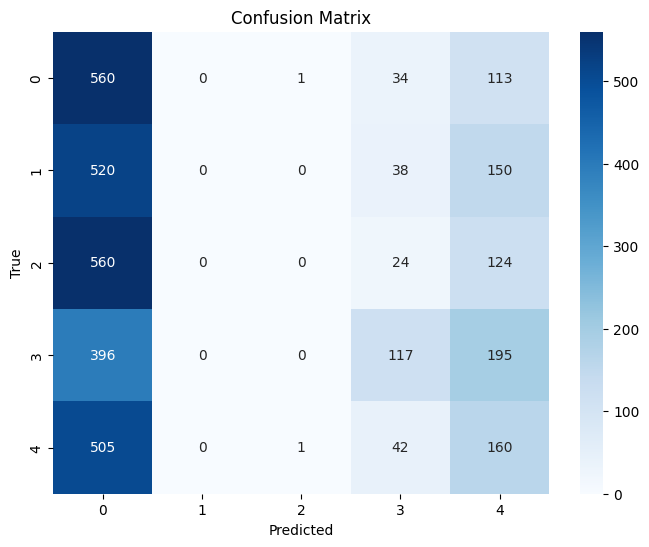


Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.79      0.34       708
           1       0.00      0.00      0.00       708
           2       0.00      0.00      0.00       708
           3       0.46      0.17      0.24       708
           4       0.22      0.23      0.22       708

    accuracy                           0.24      3540
   macro avg       0.18      0.24      0.16      3540
weighted avg       0.18      0.24      0.16      3540



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# prompt: display the confusion matrix and classification report

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'labels' and 'pred_labels' are defined from the previous code

cm = confusion_matrix(labels, pred_labels)
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(labels, pred_labels))